Paquetes necesarios

Podremos hacer uso del mismo *environment* de la primera práctica, aunque en ocasiones pedirá instalar Pillow

In [39]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

### Resolución de la tarea 1

[[44625]
 [48705]
 [49725]
 [45390]
 [49470]
 [45645]
 [51765]
 [46920]
 [49215]
 [47175]
 [48705]
 [46410]
 [56100]
 [43350]
 [45135]
 [52020]
 [45900]
 [44880]
 [48960]
 [42585]
 [51000]
 [51255]
 [36720]
 [49470]
 [49470]
 [42075]
 [46665]
 [48450]
 [40800]
 [44115]
 [42840]
 [42840]
 [41565]
 [40800]
 [35445]
 [34680]
 [33915]
 [34935]
 [24990]
 [29325]
 [26265]
 [24990]
 [28305]
 [29580]
 [27540]
 [24480]
 [25755]
 [26775]
 [33405]
 [31620]
 [35700]
 [41820]
 [39780]
 [34935]
 [35700]
 [36975]
 [36465]
 [34935]
 [34935]
 [36975]
 [39780]
 [35700]
 [39525]
 [40290]
 [34935]
 [36975]
 [34425]
 [42840]
 [37740]
 [34935]
 [40800]
 [39525]
 [44370]
 [38505]
 [37485]
 [36720]
 [37995]
 [38760]
 [39525]
 [40800]
 [40800]
 [37740]
 [49470]
 [45390]
 [48195]
 [43860]
 [49980]
 [46410]
 [50745]
 [44625]
 [47430]
 [48195]
 [46410]
 [45645]
 [48705]
 [49470]
 [46665]
 [44880]
 [50235]
 [41820]
 [54060]
 [47685]
 [42075]
 [41310]
 [42585]
 [36210]
 [42840]
 [37230]
 [41820]
 [33660]
 [47175]
 

(0.0, 512.0)

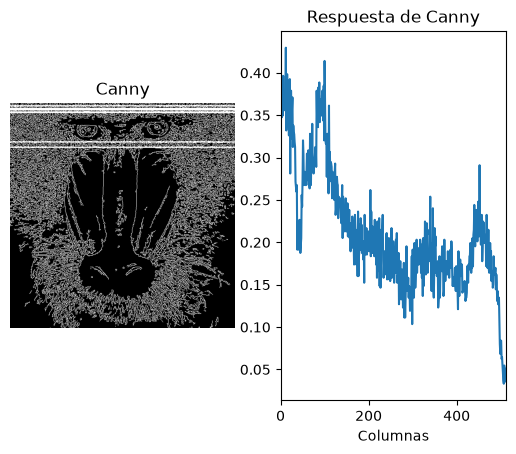

In [46]:

img = cv2.imread('mandril.jpg')
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 100, 200) #prueba a jugar con umbrales (entre 0 y 255)
#print(canny) #Muestra contenido, valores 0 o 255
#Visualiza resultado
#El contenido de la imagen resultado de Canny, son valores 0 o 255, lo compruebas al descomentar
#print(canny)

#Cuenta el número de píxeles blancos (255) por columna
#Suma los valores de los pixeles por columna

#El método reduce una imagen pasada por canny a una matriz de una columna y obtiene la suma
col_counts = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
cols = col_counts[0] / (255 * canny.shape[0])

row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por columna
rows = row_counts[:] / (255 * canny.shape[0])
maxfil = np.max(row_counts)

print(row_counts)
print(maxfil)


for i in range(len(row_counts)):
    if row_counts[i] >= maxfil*0.9:
        #canny[i,:] = 255
        cv2.line(canny,(0, i),(canny.shape[1],i),(255,0,0),2)

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(rows)
#Rango en x definido por las columnas
plt.xlim([0, canny.shape[1]])

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

## Resolución de la tarea 2

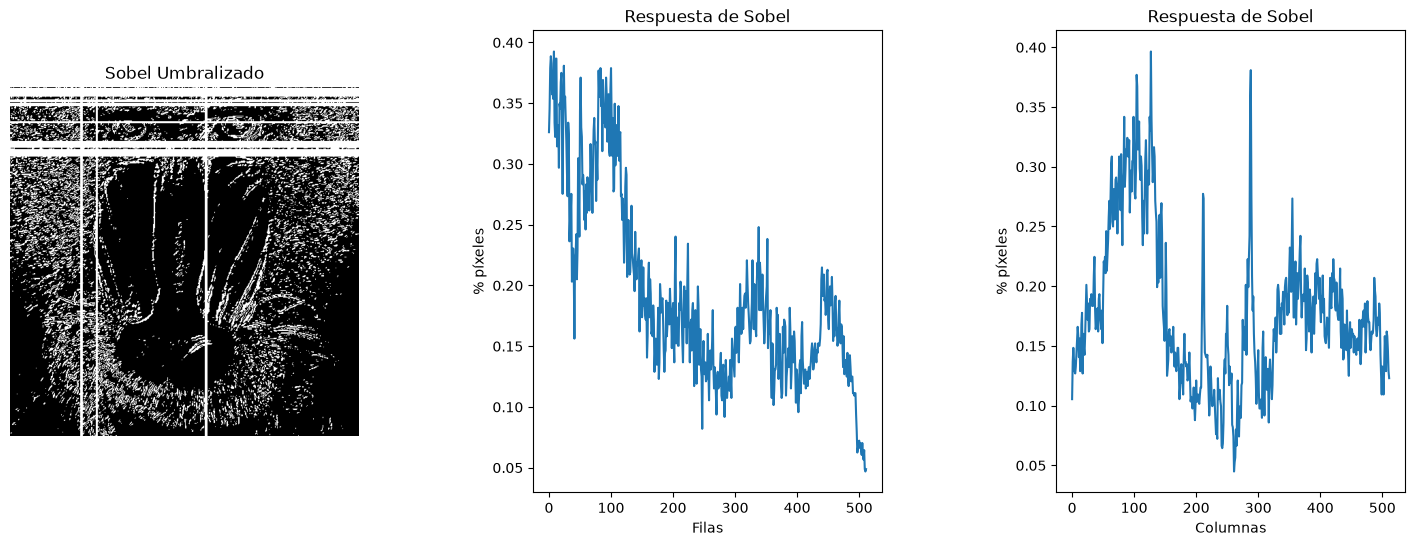

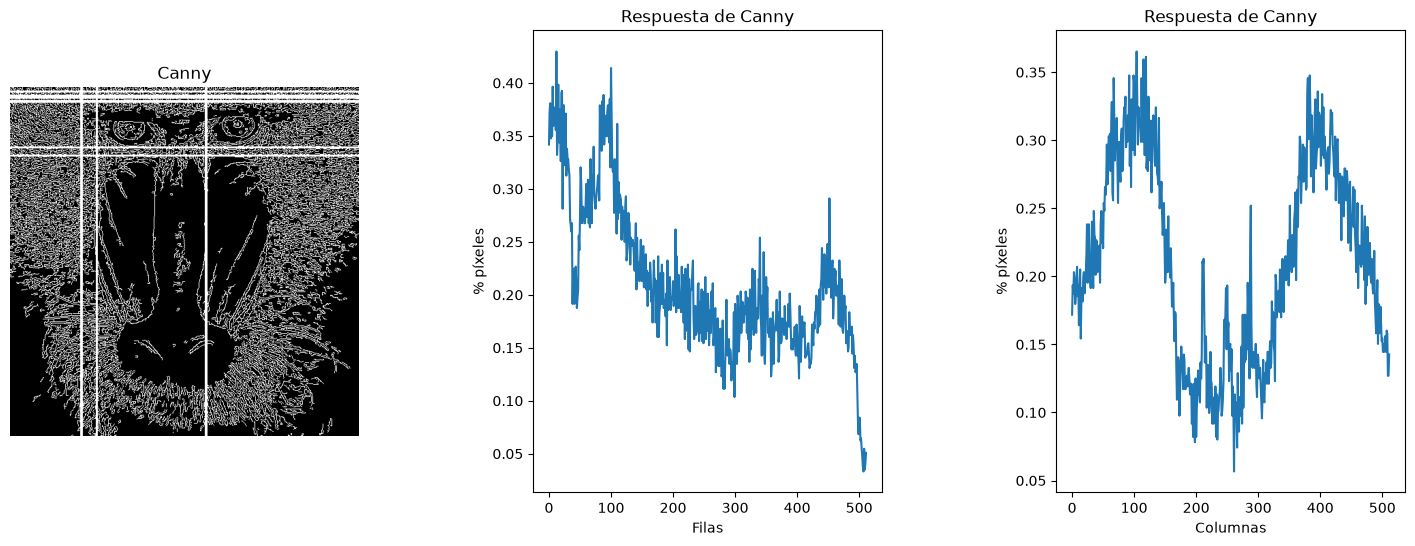

In [41]:
#Define valor umbral
valorUmbral = 100


ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)

sobel8np = np.uint8(np.abs(sobel))
#Obtiene imagen umbralizada para dicho valor definido
_, sobelUmbralizado = cv2.threshold(sobel8np, valorUmbral, 255, cv2.THRESH_BINARY)

#Lista con una lista con los valores de la suma de los píxeles por columna
col_counts = cv2.reduce(sobelUmbralizado, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Valores normalizados de la suma de los píxeles por columna, en base al número de filas y al valor máximo del píxel (255)
#Para el histograma
colsSobel = col_counts[0] / (255 * sobelUmbralizado.shape[0])
maxcolSobel = np.max(col_counts)

#Valor máximo de la suma de columnas de Canny
maxcol = np.max(col_counts)

for i in range(len(col_counts[0])):
    if col_counts[0][i] >= maxcolSobel*0.9:
        cv2.line(sobelUmbralizado,(i,0),(i,sobelUmbralizado.shape[1]),(255,0,0),2)

row_countsSobel = cv2.reduce(sobelUmbralizado, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
rowsSobel = row_countsSobel[:] / (255 * sobelUmbralizado.shape[0])
maxfilSobel = np.max(row_countsSobel)

for i in range(len(row_countsSobel)):
    if row_countsSobel[i] >= maxfilSobel*0.9:
        cv2.line(sobelUmbralizado,(0,i),(sobelUmbralizado.shape[1],i),(255,0,0),2)


for i in range(len(col_counts[0])):
    if col_counts[0][i] >= maxcol*0.9:
        cv2.line(canny,(i,0),(i,canny.shape[1]),(255,0,0),2)



plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.axis("off")
plt.title("Sobel Umbralizado")
plt.imshow(sobelUmbralizado, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("Respuesta de Sobel")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rowsSobel)

plt.subplot(1, 3, 3)
plt.title("Respuesta de Sobel")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(colsSobel)

plt.subplots_adjust(wspace=0.5)

plt.show()


plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows)

plt.subplot(1, 3, 3)
plt.title("Respuesta de Canny")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(cols)

plt.subplots_adjust(wspace=0.5)

plt.show()

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

### Resolución de la tarea 3

In [37]:
def zoom_hacia_punto(frame, punto_medio, zoom=2.0):
    """
    Hace zoom in centrado en 'punto_medio' dentro de 'frame'.
    
    frame: imagen (numpy array) de OpenCV
    punto_medio: tupla (x, y) hacia donde se hace zoom
    zoom: factor de ampliación (2.0 = el doble de "cerca")
    """
    h, w = frame.shape[:2]
    cx, cy = punto_medio

    # Tamaño de la región que vamos a recortar (más pequeña cuanto mayor sea el zoom)
    new_w = int(w / zoom)
    new_h = int(h / zoom)

    # Calculamos el rectángulo de recorte centrado en (cx, cy)
    x1 = cx - new_w // 2
    y1 = cy - new_h // 2
    x2 = x1 + new_w
    y2 = y1 + new_h

    # Nos aseguramos de que el recorte no se salga de los límites de la imagen
    if x1 < 0:
        x2 -= x1
        x1 = 0
    if y1 < 0:
        y2 -= y1
        y1 = 0
    if x2 > w:
        x1 -= (x2 - w)
        x2 = w
    if y2 > h:
        y1 -= (y2 - h)
        y2 = h

    # Por si tras los ajustes queda algún valor negativo
    x1 = np.max(x1, 0)
    y1 = np.max(y1, 0)

    recorte = frame[y1:y2, x1:x2]

    # Redimensionamos el recorte al tamaño original del frame
    zoom_img = cv2.resize(recorte, (w, h), interpolation=cv2.INTER_CUBIC)

    return zoom_img

In [38]:
vid=cv2.VideoCapture(0)
punto_medio = None
zoom = 0.1

while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()
    # Hay nuevo fotograma
    if ret: 
        detector = cv2.FaceDetectorYN.create(
        "face_detection_yunet_2023mar.onnx",
        "",
        (320, 320),
        0.9,   # score_threshold
        0.3,   # nms_threshold
        5000   # top_k
        )

        #img = cv2.imread("images (1).jpg")

        # Ajustar el tamaño de entrada a la imagen
        h, w = frame.shape[:2]
        detector.setInputSize((w, h))

        # Detectar caras
        _, faces = detector.detect(frame)

        if faces is not None:
            x, y, fw, fh = faces[0][:4].astype(int)

            punto_medio = (x + fw // 2, y + fh // 2)
            cv2.circle(frame, punto_medio, 5, (0, 0, 255), -1)

            frame = zoom_hacia_punto(frame, punto_medio, zoom)

            if zoom <= 2:
                zoom += 0.1

        else:
            if zoom > 1:
                zoom -= 0.1
            frame = zoom_hacia_punto(frame, (w//2,h//2), zoom)
    
    cv2.imshow("Zoom", frame)
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
          
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()


### Ventana que cambia de tamaño si te mueves (adición graciosa resultante de toquetear)

In [ ]:
vid=cv2.VideoCapture(0)


while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()
    max = 0
    min = float('inf')
    # Hay nuevo fotograma
    if ret: 
        detector = cv2.FaceDetectorYN.create(
        "face_detection_yunet_2023mar.onnx",
        "",
        (320, 320),
        0.9,   # score_threshold
        0.3,   # nms_threshold
        5000   # top_k
        )

        #img = cv2.imread("images (1).jpg")

        # Ajustar el tamaño de entrada a la imagen
        h, w = frame.shape[:2]
        detector.setInputSize((w, h))

        # Detectar caras
        _, faces = detector.detect(frame)

        if faces is not None:
            for face in faces:
                x, y, fw, fh = face[:4].astype(int)

                cv2.rectangle(
                    frame,
                    (x, y),
                    (x + fw, y + fh),
                    (0, 255, 0),
                    2
                )

                punto_medio = (x + fw // 2, y + fh // 2)
                cv2.circle(frame, punto_medio, 5, (0, 0, 255), -1)

                frame = cv2.resize( frame, punto_medio, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)

    cv2.imshow("Caras", frame)
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
          
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()
